# Representation Learning With PCA and Autoencoders

This notebook solves the assignment tasks for MNIST and CIFAR10 converted to gray level.

Requirements implemented:

- MNIST and CIFAR10 loaded from `tensorflow.keras.datasets`
- CIFAR10 converted to gray level
- both datasets resized to 28 x 28
- intensities rescaled to [50, 200]
- random 70% / 20% / 10% train / validation / test split
- standard PCA and randomized PCA with 30 components
- logistic regression classification on PCA features and autoencoder features
- multiclass ROC curves
- reconstruction SNR in dB
- tied-weight linear autoencoder with unit-magnitude encoder vectors
- component/weight visualization and quantitative PCA-AE comparison
- deep convolutional autoencoder with 30-dimensional latent space
- single hidden layer and three hidden layer dense autoencoder comparisons

Before running:

```python
# Uncomment if your environment is missing packages.
# %pip install -q tensorflow scikit-learn matplotlib pandas seaborn
```



In [26]:
import os
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler

from scipy.optimize import linear_sum_assignment

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")



## Configuration

`FAST_MODE=False` runs the full 70/20/10 split required by the assignment.
If you only want to verify that the notebook executes, set `FAST_MODE=True`.



In [27]:
RANDOM_SEED = 42
FAST_MODE = True

N_COMPONENTS = 30
IMAGE_SHAPE = (28, 28)
N_CLASSES = 10

BATCH_SIZE = 256
LINEAR_AE_EPOCHS = 80
DENSE_AE_EPOCHS = 60
CONV_AE_EPOCHS = 50
PATIENCE = 8

if FAST_MODE:
    # Small values for quick smoke tests only. Leave FAST_MODE=False for submission runs.
    MAX_TOTAL_PER_DATASET = 12000
    LINEAR_AE_EPOCHS = 10
    DENSE_AE_EPOCHS = 8
    CONV_AE_EPOCHS = 8
else:
    MAX_TOTAL_PER_DATASET = None

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow:", tf.__version__)
print("FAST_MODE:", FAST_MODE)



TensorFlow: 2.20.0
FAST_MODE: True


## Helper Functions



In [28]:
@dataclass
class DatasetSplit:
    name: str
    x_train_img_50_200: np.ndarray
    y_train: np.ndarray
    x_val_img_50_200: np.ndarray
    y_val: np.ndarray
    x_test_img_50_200: np.ndarray
    y_test: np.ndarray

    @property
    def x_train_flat_50_200(self):
        return self.x_train_img_50_200.reshape(len(self.x_train_img_50_200), -1)

    @property
    def x_val_flat_50_200(self):
        return self.x_val_img_50_200.reshape(len(self.x_val_img_50_200), -1)

    @property
    def x_test_flat_50_200(self):
        return self.x_test_img_50_200.reshape(len(self.x_test_img_50_200), -1)

    @property
    def x_train_01(self):
        return (self.x_train_img_50_200 - 50.0) / 150.0

    @property
    def x_val_01(self):
        return (self.x_val_img_50_200 - 50.0) / 150.0

    @property
    def x_test_01(self):
        return (self.x_test_img_50_200 - 50.0) / 150.0

    @property
    def x_train_flat_01(self):
        return self.x_train_01.reshape(len(self.x_train_01), -1)

    @property
    def x_val_flat_01(self):
        return self.x_val_01.reshape(len(self.x_val_01), -1)

    @property
    def x_test_flat_01(self):
        return self.x_test_01.reshape(len(self.x_test_01), -1)


def set_all_seeds(seed=RANDOM_SEED):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)


def to_50_200(x):
    """Map image intensities from [0, 255] to [50, 200]."""
    x = x.astype("float32")
    return 50.0 + (x / 255.0) * 150.0


def preprocess_mnist_images(x):
    x = x.astype("float32")
    if x.ndim == 3:
        x = x[..., np.newaxis]
    # MNIST is already 28 x 28; keep this call for a consistent pipeline.
    x = tf.image.resize(x, IMAGE_SHAPE, method="bilinear").numpy()
    return to_50_200(x)


def preprocess_cifar10_images(x):
    x = x.astype("float32")
    # ITU-R BT.601 luminance conversion.
    gray = 0.299 * x[..., 0] + 0.587 * x[..., 1] + 0.114 * x[..., 2]
    gray = gray[..., np.newaxis]
    gray = tf.image.resize(gray, IMAGE_SHAPE, method="bilinear").numpy()
    return to_50_200(gray)


def make_split(name, x, y, max_total=None):
    y = y.reshape(-1).astype("int64")

    if max_total is not None and max_total < len(x):
        rng = np.random.default_rng(RANDOM_SEED)
        idx = rng.choice(len(x), size=max_total, replace=False)
        x = x[idx]
        y = y[idx]

    # First split off 10% test, then split the remaining 90% into 70/20.
    x_temp, x_test, y_temp, y_test = train_test_split(
        x,
        y,
        test_size=0.10,
        random_state=RANDOM_SEED,
        stratify=y,
    )
    val_fraction_of_temp = 0.20 / 0.90
    x_train, x_val, y_train, y_val = train_test_split(
        x_temp,
        y_temp,
        test_size=val_fraction_of_temp,
        random_state=RANDOM_SEED,
        stratify=y_temp,
    )

    return DatasetSplit(name, x_train, y_train, x_val, y_val, x_test, y_test)


def mean_snr_db(original, reconstructed, eps=1e-10):
    """Average per-image SNR in dB: 10 log10(signal_power / noise_power)."""
    original = original.reshape(len(original), -1).astype("float64")
    reconstructed = reconstructed.reshape(len(reconstructed), -1).astype("float64")
    signal_power = np.mean(original**2, axis=1)
    noise_power = np.mean((original - reconstructed) ** 2, axis=1)
    return float(np.mean(10.0 * np.log10((signal_power + eps) / (noise_power + eps))))


def plot_component_grid(components, title, n_rows=5, n_cols=6, image_shape=IMAGE_SHAPE, cmap="gray"):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
    fig.suptitle(title, fontsize=15, y=0.98)
    for i, ax in enumerate(axes.ravel()):
        comp = components[i].reshape(image_shape)
        ax.imshow(comp, cmap=cmap)
        ax.set_title(f"{i + 1}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def plot_reconstruction_examples(original, reconstructed, title, n=8):
    original = original[:n].reshape(n, *IMAGE_SHAPE)
    reconstructed = reconstructed[:n].reshape(n, *IMAGE_SHAPE)
    fig, axes = plt.subplots(2, n, figsize=(1.7 * n, 3.6))
    fig.suptitle(title, fontsize=14)
    for i in range(n):
        axes[0, i].imshow(original[i], cmap="gray", vmin=50, vmax=200)
        axes[0, i].axis("off")
        axes[0, i].set_title("Test", fontsize=8)
        axes[1, i].imshow(reconstructed[i], cmap="gray", vmin=50, vmax=200)
        axes[1, i].axis("off")
        axes[1, i].set_title("Recon", fontsize=8)
    plt.tight_layout()
    plt.show()


def fit_logistic_and_roc(z_train, y_train, z_test, y_test, title):
    clf = LogisticRegression(
        max_iter=1500,
        solver="lbfgs",
        multi_class="auto",
        n_jobs=-1,
        random_state=RANDOM_SEED,
    )
    clf.fit(z_train, y_train)
    y_pred = clf.predict(z_test)
    y_score = clf.predict_proba(z_test)

    acc = accuracy_score(y_test, y_pred)
    macro_auc = roc_auc_score(y_test, y_score, multi_class="ovr", average="macro")

    y_test_bin = label_binarize(y_test, classes=np.arange(N_CLASSES))
    fpr = {}
    tpr = {}
    roc_auc = {}
    for class_id in range(N_CLASSES):
        fpr[class_id], tpr[class_id], _ = roc_curve(y_test_bin[:, class_id], y_score[:, class_id])
        roc_auc[class_id] = auc(fpr[class_id], tpr[class_id])

    plt.figure(figsize=(8, 6))
    for class_id in range(N_CLASSES):
        plt.plot(fpr[class_id], tpr[class_id], lw=1.2, label=f"Class {class_id} AUC={roc_auc[class_id]:.3f}")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"{title}\nAccuracy={acc:.4f}, macro AUC={macro_auc:.4f}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    return clf, {"accuracy": acc, "macro_auc": macro_auc}


def compare_component_spaces(pca_components, ae_components, dataset_name):
    """Compare PCA components and AE weight vectors.

    Both inputs should have shape (n_components, n_pixels).
    Sign is ignored because eigenvectors are sign-ambiguous.
    """
    pca_norm = pca_components / np.linalg.norm(pca_components, axis=1, keepdims=True)
    ae_norm = ae_components / np.linalg.norm(ae_components, axis=1, keepdims=True)

    abs_cos = np.abs(pca_norm @ ae_norm.T)
    row_ind, col_ind = linear_sum_assignment(-abs_cos)
    matched = abs_cos[row_ind, col_ind]

    singular_values = np.linalg.svd(pca_norm @ ae_norm.T, compute_uv=False)
    principal_angles_deg = np.degrees(np.arccos(np.clip(singular_values, -1, 1)))

    summary = {
        "dataset": dataset_name,
        "mean_matched_abs_cosine": float(np.mean(matched)),
        "median_matched_abs_cosine": float(np.median(matched)),
        "min_matched_abs_cosine": float(np.min(matched)),
        "mean_subspace_singular_value": float(np.mean(singular_values)),
        "max_principal_angle_deg": float(np.max(principal_angles_deg)),
    }
    return summary, abs_cos, matched, principal_angles_deg


def early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
    )


def to_keras_images_01(x_01):
    return x_01.astype("float32")


def flat01_to_50_200(x_flat_01):
    x_flat_01 = np.clip(x_flat_01, 0.0, 1.0)
    return 50.0 + 150.0 * x_flat_01



## Load and Preprocess Datasets



In [12]:
print("Loading MNIST and CIFAR10 from Keras...")
(mnist_x_train_raw, mnist_y_train_raw), (mnist_x_test_raw, mnist_y_test_raw) = keras.datasets.mnist.load_data()
(cifar_x_train_raw, cifar_y_train_raw), (cifar_x_test_raw, cifar_y_test_raw) = keras.datasets.cifar10.load_data()

mnist_x_raw = np.concatenate([mnist_x_train_raw, mnist_x_test_raw], axis=0)
mnist_y_raw = np.concatenate([mnist_y_train_raw, mnist_y_test_raw], axis=0)
cifar_x_raw = np.concatenate([cifar_x_train_raw, cifar_x_test_raw], axis=0)
cifar_y_raw = np.concatenate([cifar_y_train_raw, cifar_y_test_raw], axis=0)

mnist_x = preprocess_mnist_images(mnist_x_raw)
cifar_x = preprocess_cifar10_images(cifar_x_raw)

mnist = make_split("MNIST", mnist_x, mnist_y_raw, max_total=MAX_TOTAL_PER_DATASET)
cifar10_gray = make_split("CIFAR10-gray", cifar_x, cifar_y_raw, max_total=MAX_TOTAL_PER_DATASET)
datasets = [mnist, cifar10_gray]

for ds in datasets:
    print(
        f"{ds.name}: train={len(ds.y_train)}, validation={len(ds.y_val)}, test={len(ds.y_test)}, "
        f"range=({ds.x_train_img_50_200.min():.1f}, {ds.x_train_img_50_200.max():.1f})"
    )



Loading MNIST and CIFAR10 from Keras...
MNIST: train=8400, validation=2400, test=1200, range=(50.0, 200.0)
CIFAR10-gray: train=8400, validation=2400, test=1200, range=(50.0, 200.0)


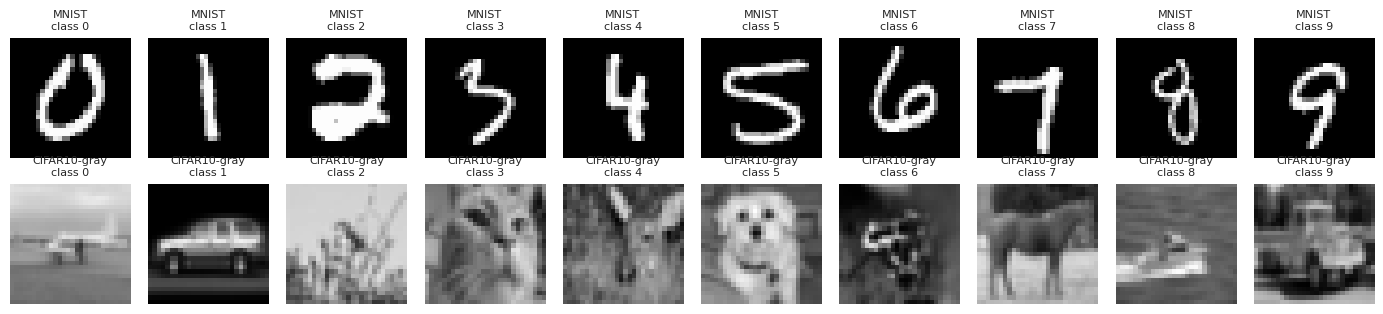

In [13]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for row, ds in enumerate(datasets):
    for col in range(10):
        idx = np.where(ds.y_train == col)[0][0]
        axes[row, col].imshow(ds.x_train_img_50_200[idx].squeeze(), cmap="gray", vmin=50, vmax=200)
        axes[row, col].set_title(f"{ds.name}\nclass {col}", fontsize=8)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()



# Task 1: Standard PCA, Randomized PCA, Logistic Regression, ROC and SNR

For each dataset, PCA is fitted using the 70% training split. The first 30 principal components are then used as
features for a multinomial logistic regression classifier. Reconstruction SNR is computed on the 10% test split.




MNIST: fitting standard PCA


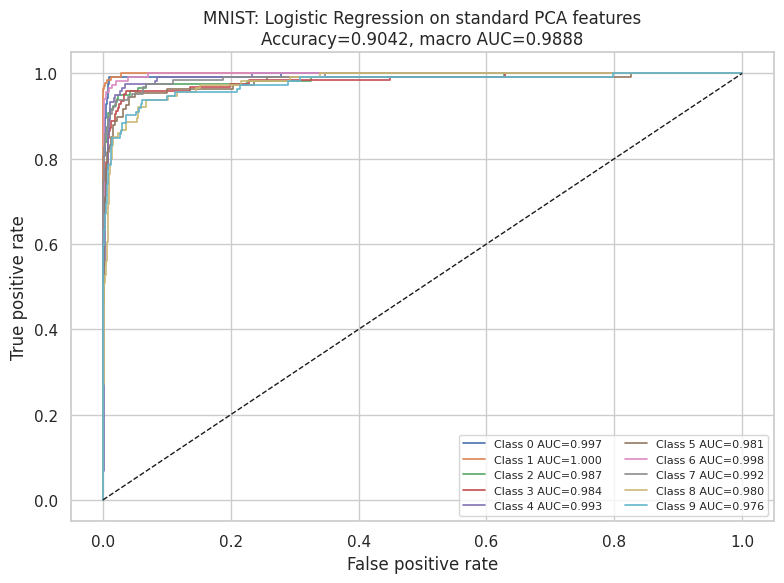


MNIST: fitting randomized PCA


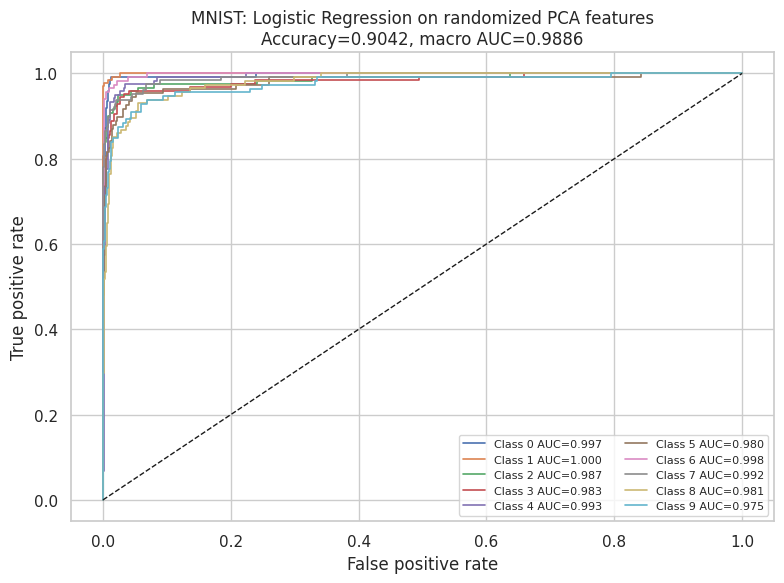


CIFAR10-gray: fitting standard PCA


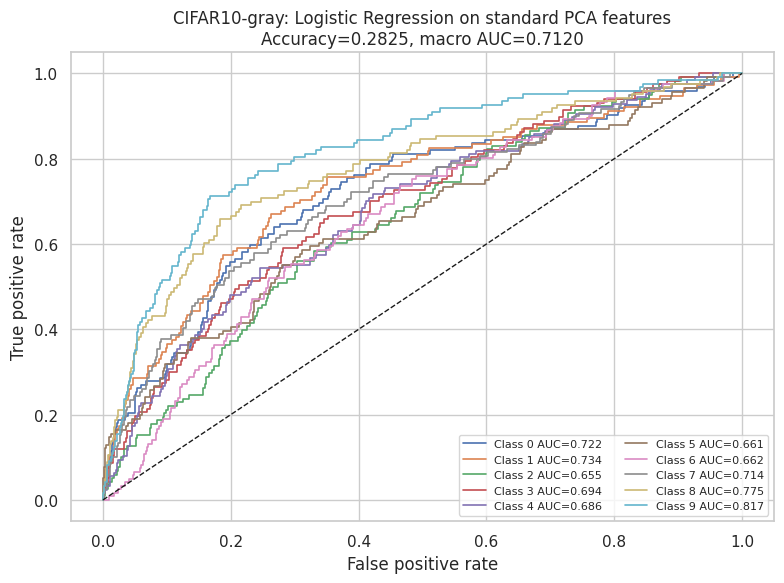


CIFAR10-gray: fitting randomized PCA


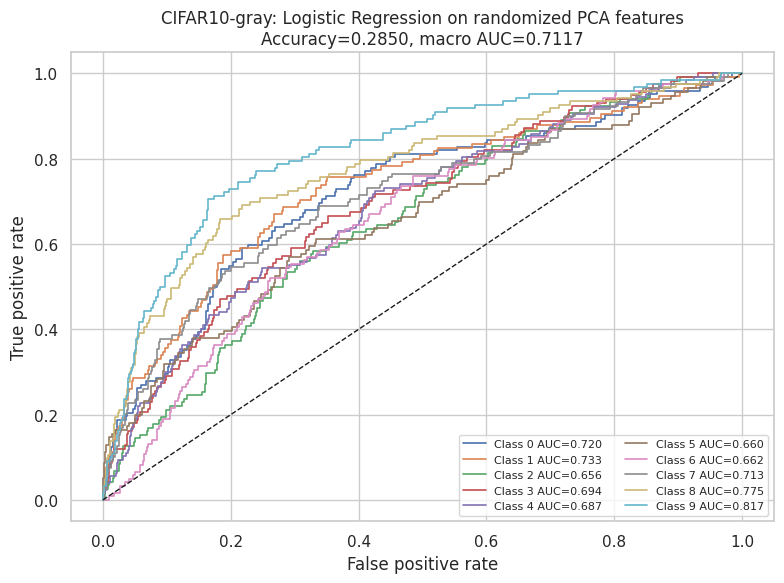

,dataset,method,components,accuracy,macro_auc_ovr,explained_variance_ratio_sum,average_test_snr_db
0,MNIST,standard PCA,30,0.904167,0.988758,0.733744,12.575018
1,MNIST,randomized PCA,30,0.904167,0.988550,0.733691,12.573960
2,CIFAR10-gray,standard PCA,30,0.282500,0.711971,0.851137,20.003669
3,CIFAR10-gray,randomized PCA,30,0.285000,0.711737,0.851111,20.000278


In [14]:
task1_rows = []
task1_models = {}

for ds in datasets:
    for solver_name, svd_solver in [("standard PCA", "full"), ("randomized PCA", "randomized")]:
        print(f"\n{ds.name}: fitting {solver_name}")
        pca = PCA(
            n_components=N_COMPONENTS,
            svd_solver=svd_solver,
            random_state=RANDOM_SEED,
            iterated_power=5 if svd_solver == "randomized" else "auto",
        )
        pca.fit(ds.x_train_flat_50_200)

        z_train = pca.transform(ds.x_train_flat_50_200)
        z_test = pca.transform(ds.x_test_flat_50_200)
        recon_test = pca.inverse_transform(z_test)
        snr = mean_snr_db(ds.x_test_flat_50_200, recon_test)

        clf, metrics = fit_logistic_and_roc(
            z_train,
            ds.y_train,
            z_test,
            ds.y_test,
            title=f"{ds.name}: Logistic Regression on {solver_name} features",
        )

        task1_rows.append(
            {
                "dataset": ds.name,
                "method": solver_name,
                "components": N_COMPONENTS,
                "accuracy": metrics["accuracy"],
                "macro_auc_ovr": metrics["macro_auc"],
                "explained_variance_ratio_sum": float(np.sum(pca.explained_variance_ratio_)),
                "average_test_snr_db": snr,
            }
        )
        task1_models[(ds.name, solver_name)] = {
            "pca": pca,
            "clf": clf,
            "z_train": z_train,
            "z_test": z_test,
            "recon_test": recon_test,
        }

task1_results = pd.DataFrame(task1_rows)
task1_results



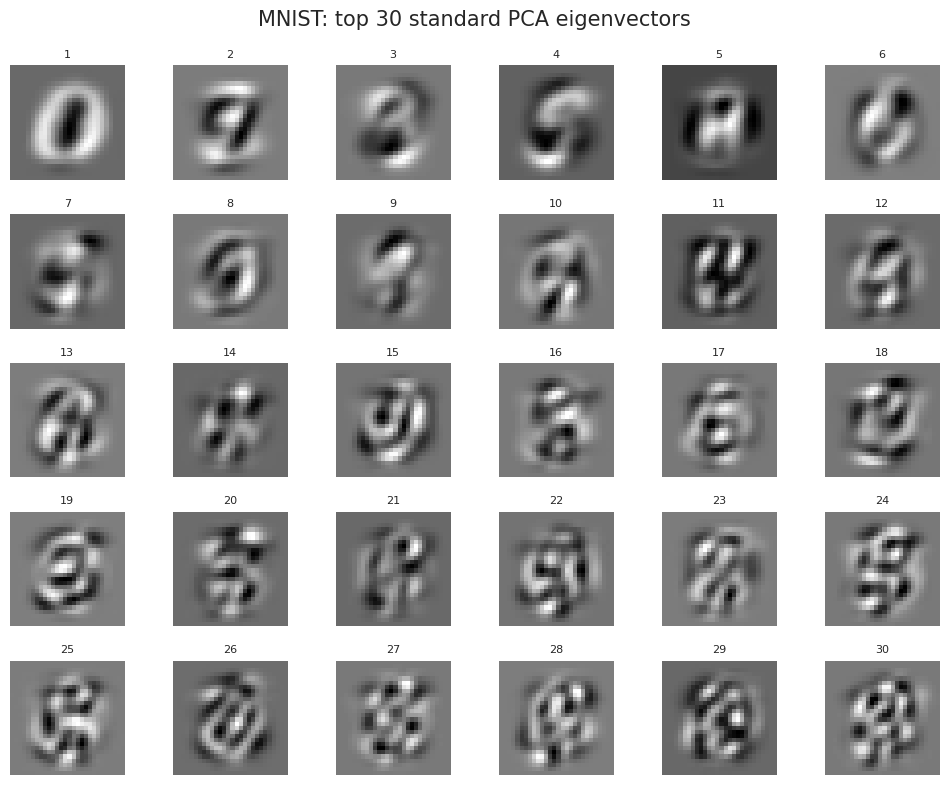

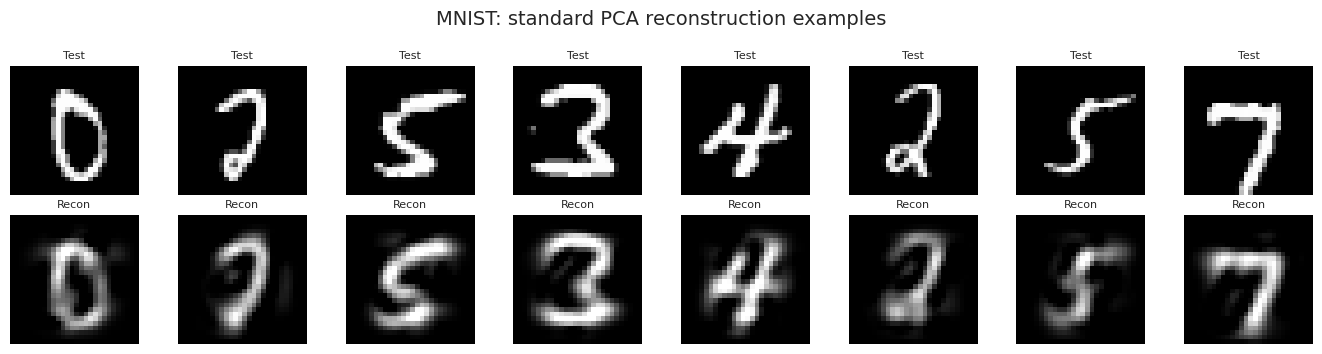

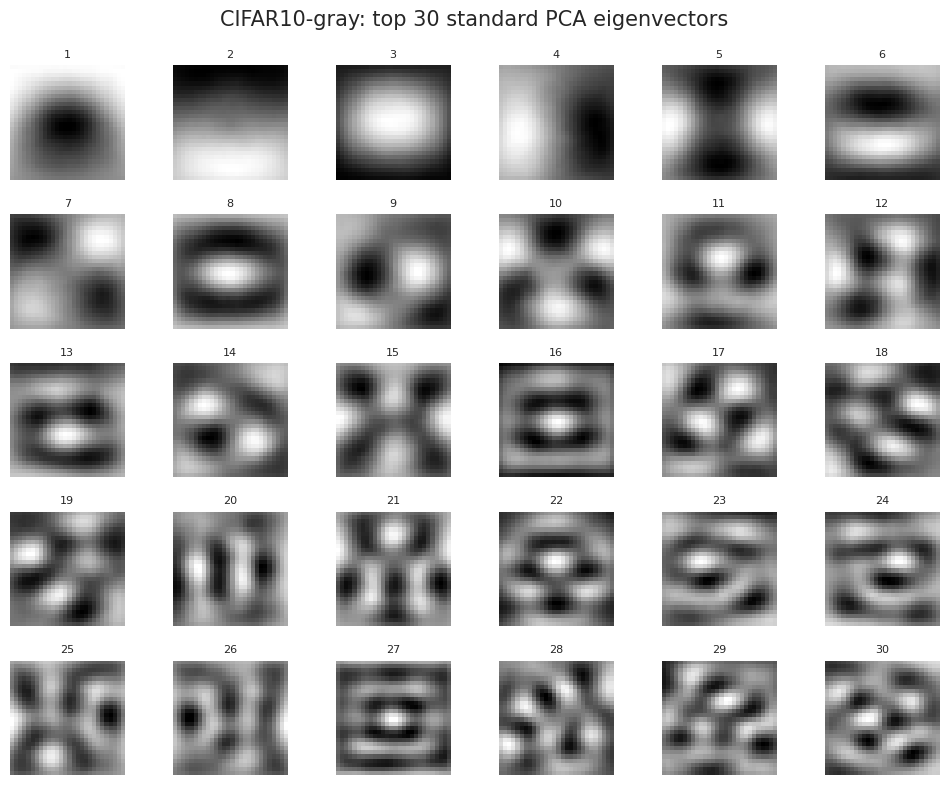

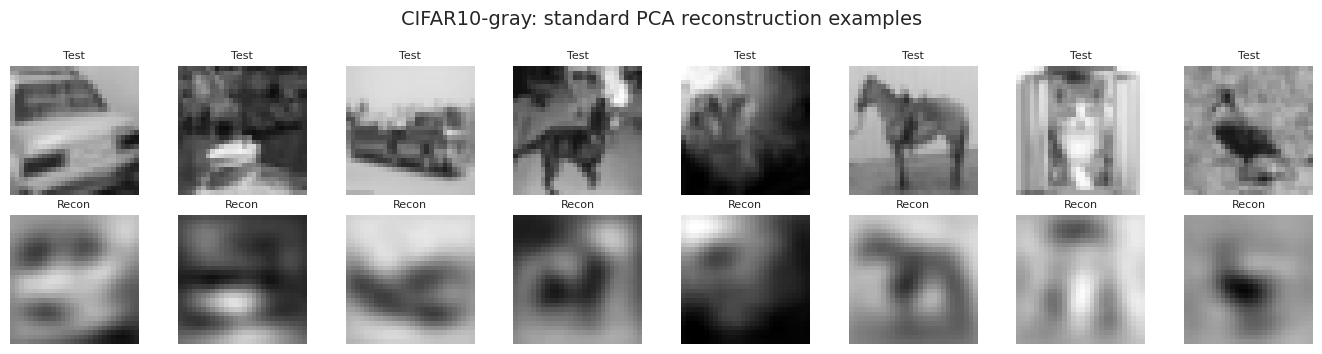

In [15]:
for ds in datasets:
    pca = task1_models[(ds.name, "standard PCA")]["pca"]
    plot_component_grid(pca.components_, f"{ds.name}: top 30 standard PCA eigenvectors")
    recon = task1_models[(ds.name, "standard PCA")]["recon_test"]
    plot_reconstruction_examples(ds.x_test_flat_50_200, recon, f"{ds.name}: standard PCA reconstruction examples")



**Task 1 comments.**

Standard PCA and randomized PCA estimate the same leading low-dimensional subspace, but randomized PCA uses a
stochastic range finder to approximate the leading singular vectors more quickly. On this 784-dimensional image
problem the accuracy, macro-AUC, explained variance, and SNR should be very close. Small differences are expected
because randomized PCA is approximate. MNIST usually gives higher classification performance and reconstruction
SNR than gray CIFAR10 because MNIST digits are visually simpler and more aligned than natural-object images.



# Task 2: Tied-Weight Linear Autoencoder and PCA Relationship

The linear autoencoder uses standardized input and the decoder weight matrix is the transpose of the encoder
matrix. Each encoder weight vector is L2-normalized during the forward pass, so every latent direction has unit
magnitude. A linear tied-weight autoencoder trained with MSE on centered data should learn the same principal
subspace as PCA, although individual learned vectors may be sign-flipped or rotated inside the 30-dimensional
subspace.




Training tied linear AE for MNIST
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.7314 - val_loss: 0.6963
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5890 - val_loss: 0.6178
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5298 - val_loss: 0.5764
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4959 - val_loss: 0.5521
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4762 - val_loss: 0.5384
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4651 - val_loss: 0.5307
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4588 - val_loss: 0.5261
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4550 - val_loss: 0.5232
Epoch 9/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4527 - val_loss: 0.5214
Epoch 10/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4511 - val_loss: 0.5201


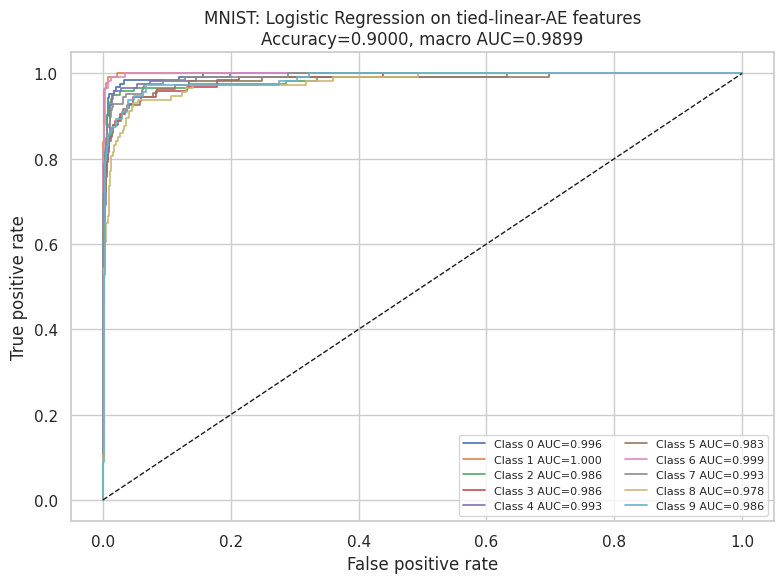


Training tied linear AE for CIFAR10-gray
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.6379 - val_loss: 0.4355
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3862 - val_loss: 0.3269
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3009 - val_loss: 0.2707
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2586 - val_loss: 0.2398
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2313 - val_loss: 0.2174
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2114 - val_loss: 0.2011
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1968 - val_loss: 0.1888
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1858 - val_loss: 0.1796
Epoch 9/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1775 - val_loss: 0.1726
Epoch 10/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1714 - val_loss: 0.1677


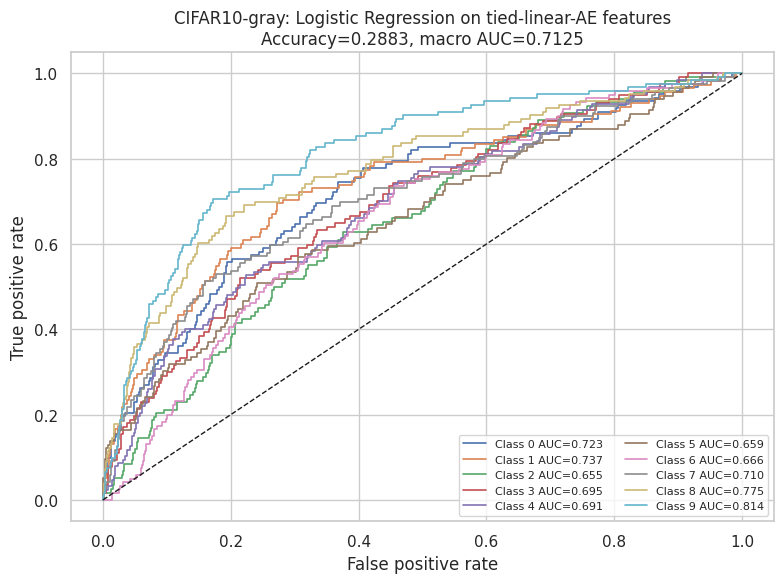

,dataset,method,components,accuracy,macro_auc_ovr,average_test_snr_db
0,MNIST,tied linear AE features,30,0.900000,0.989927,11.297852
1,CIFAR10-gray,tied linear AE features,30,0.288333,0.712465,19.590946


In [16]:
class TiedLinearAutoencoder(keras.Model):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.W = self.add_weight(
            shape=(input_dim, latent_dim),
            initializer=keras.initializers.Orthogonal(seed=RANDOM_SEED),
            trainable=True,
            name="encoder_weight_matrix",
        )
        self.b_enc = self.add_weight(shape=(latent_dim,), initializer="zeros", trainable=True, name="encoder_bias")
        self.b_dec = self.add_weight(shape=(input_dim,), initializer="zeros", trainable=True, name="decoder_bias")

    def normalized_W(self):
        return tf.linalg.l2_normalize(self.W, axis=0)

    def encode(self, x):
        Wn = self.normalized_W()
        return tf.matmul(x, Wn) + self.b_enc

    def call(self, x):
        Wn = self.normalized_W()
        z = tf.matmul(x, Wn) + self.b_enc
        return tf.matmul(z, tf.transpose(Wn)) + self.b_dec


def train_tied_linear_ae(ds):
    keras.backend.clear_session()
    scaler = StandardScaler()
    x_train_std = scaler.fit_transform(ds.x_train_flat_50_200).astype("float32")
    x_val_std = scaler.transform(ds.x_val_flat_50_200).astype("float32")
    x_test_std = scaler.transform(ds.x_test_flat_50_200).astype("float32")

    set_all_seeds()
    ae = TiedLinearAutoencoder(input_dim=x_train_std.shape[1], latent_dim=N_COMPONENTS)
    ae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    hist = ae.fit(
        x_train_std,
        x_train_std,
        validation_data=(x_val_std, x_val_std),
        epochs=LINEAR_AE_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping()],
        verbose=1,
    )

    z_train = ae.encode(tf.convert_to_tensor(x_train_std)).numpy()
    z_test = ae.encode(tf.convert_to_tensor(x_test_std)).numpy()
    recon_test_std = ae(tf.convert_to_tensor(x_test_std)).numpy()
    recon_test_50_200 = scaler.inverse_transform(recon_test_std)

    W = ae.normalized_W().numpy()
    ae_components = W.T

    return {
        "ae": ae,
        "history": hist,
        "scaler": scaler,
        "z_train": z_train,
        "z_test": z_test,
        "recon_test_50_200": recon_test_50_200,
        "ae_components": ae_components,
    }


task2_rows = []
task2_models = {}
component_compare_rows = []

for ds in datasets:
    print(f"\nTraining tied linear AE for {ds.name}")
    model_info = train_tied_linear_ae(ds)
    task2_models[ds.name] = model_info

    _, ae_metrics = fit_logistic_and_roc(
        model_info["z_train"],
        ds.y_train,
        model_info["z_test"],
        ds.y_test,
        title=f"{ds.name}: Logistic Regression on tied-linear-AE features",
    )

    ae_snr = mean_snr_db(ds.x_test_flat_50_200, model_info["recon_test_50_200"])
    task2_rows.append(
        {
            "dataset": ds.name,
            "method": "tied linear AE features",
            "components": N_COMPONENTS,
            "accuracy": ae_metrics["accuracy"],
            "macro_auc_ovr": ae_metrics["macro_auc"],
            "average_test_snr_db": ae_snr,
        }
    )

    pca_components = task1_models[(ds.name, "standard PCA")]["pca"].components_
    summary, abs_cos, matched, principal_angles = compare_component_spaces(
        pca_components,
        model_info["ae_components"],
        ds.name,
    )
    component_compare_rows.append(summary)

task2_results = pd.DataFrame(task2_rows)
task2_results



In [17]:
pd.concat(
    [
        task1_results.query("method == 'standard PCA'")[
            ["dataset", "method", "components", "accuracy", "macro_auc_ovr", "average_test_snr_db"]
        ],
        task2_results,
    ],
    ignore_index=True,
)



,dataset,method,components,accuracy,macro_auc_ovr,average_test_snr_db
0,MNIST,standard PCA,30,0.904167,0.988758,12.575018
1,CIFAR10-gray,standard PCA,30,0.282500,0.711971,20.003669
2,MNIST,tied linear AE features,30,0.900000,0.989927,11.297852
3,CIFAR10-gray,tied linear AE features,30,0.288333,0.712465,19.590946


In [18]:
component_comparison = pd.DataFrame(component_compare_rows)
component_comparison



,dataset,mean_matched_abs_cosine,median_matched_abs_cosine,min_matched_abs_cosine,mean_subspace_singular_value,max_principal_angle_deg
0,MNIST,0.303689,0.290515,0.079505,0.720208,87.911797
1,CIFAR10-gray,0.354050,0.368258,0.124365,0.879534,88.398766


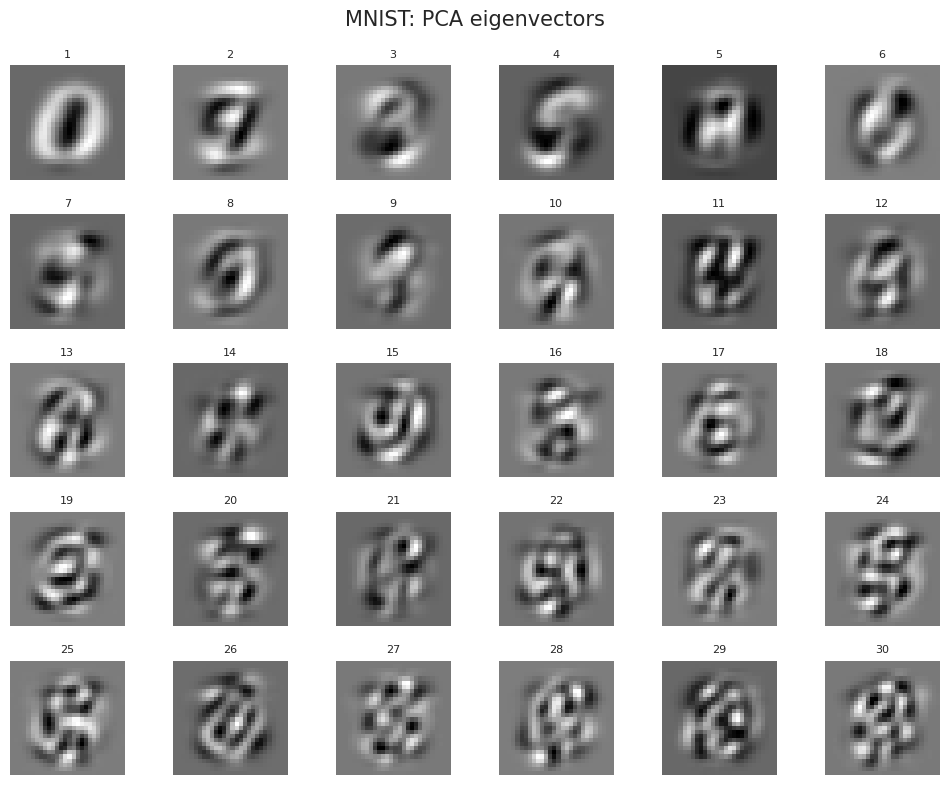

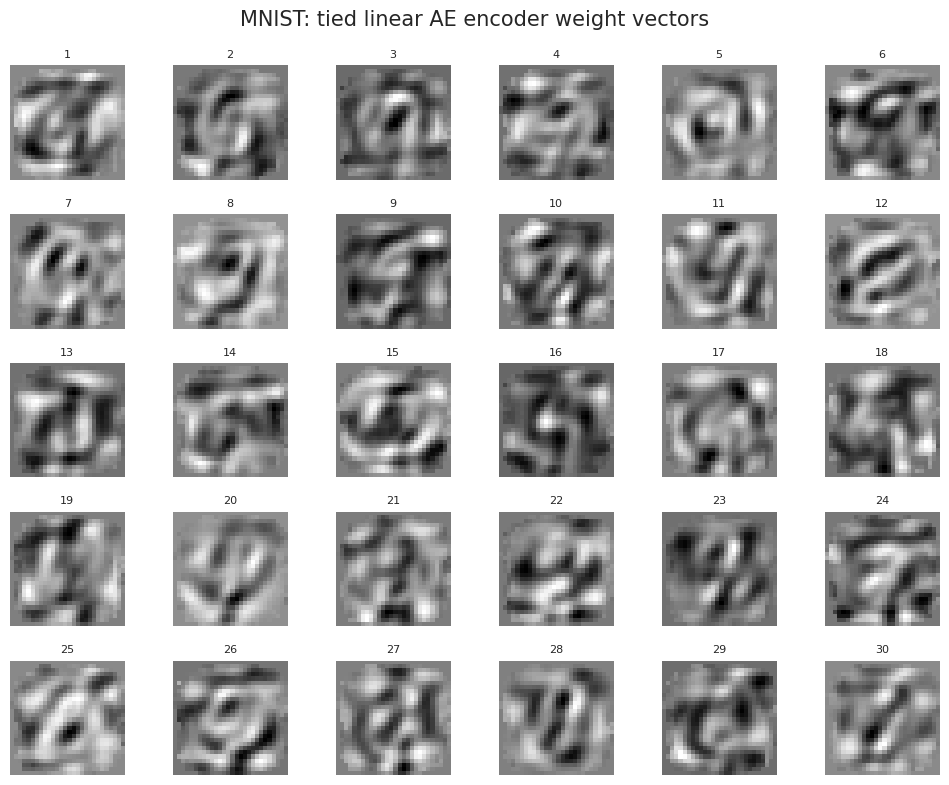

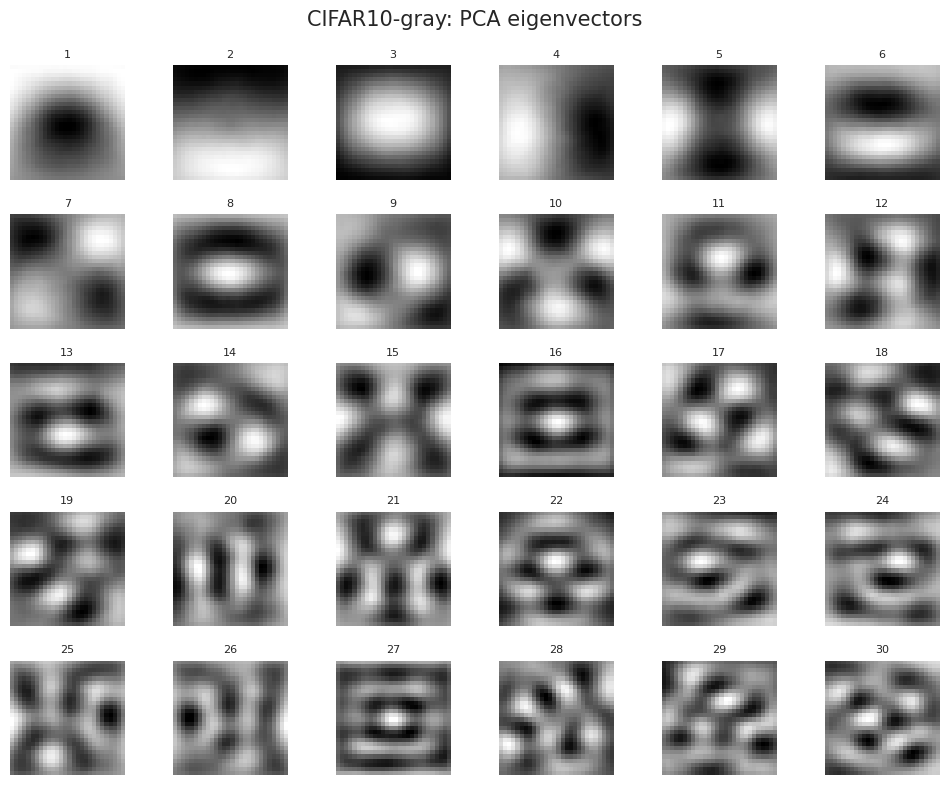

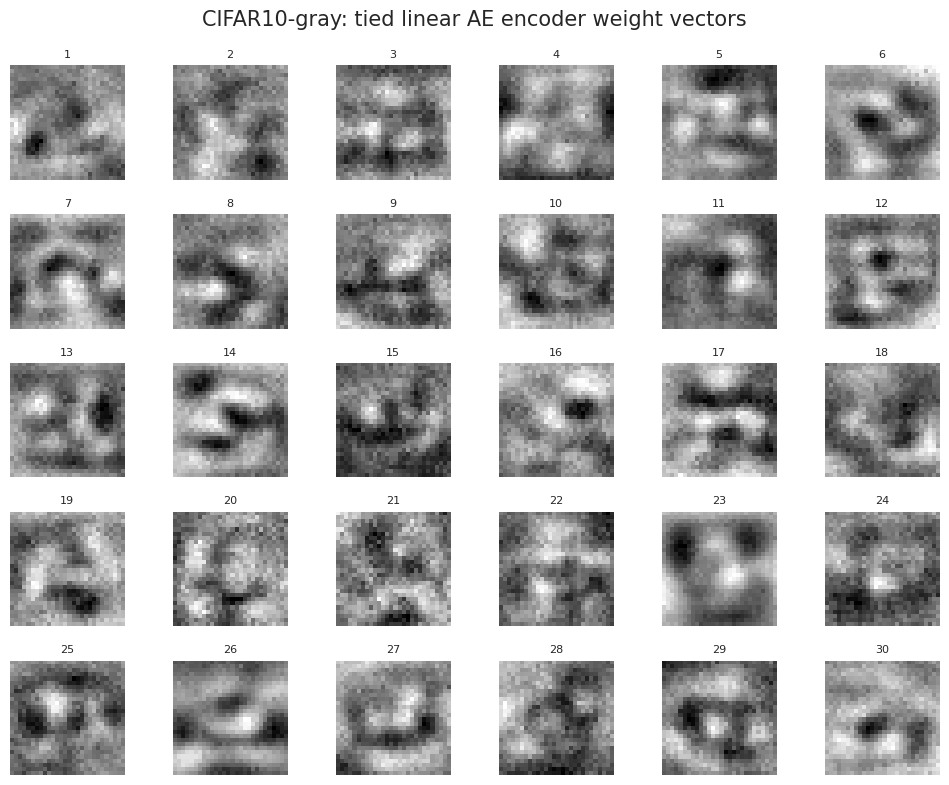

In [19]:
for ds in datasets:
    plot_component_grid(task1_models[(ds.name, "standard PCA")]["pca"].components_, f"{ds.name}: PCA eigenvectors")
    plot_component_grid(task2_models[ds.name]["ae_components"], f"{ds.name}: tied linear AE encoder weight vectors")



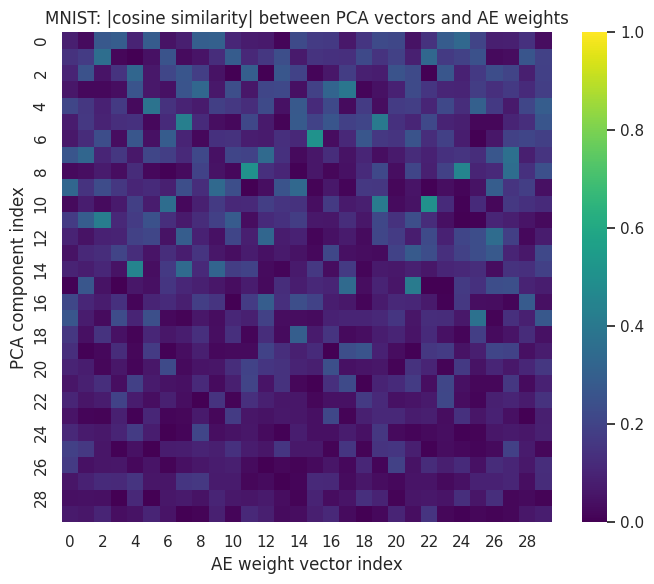

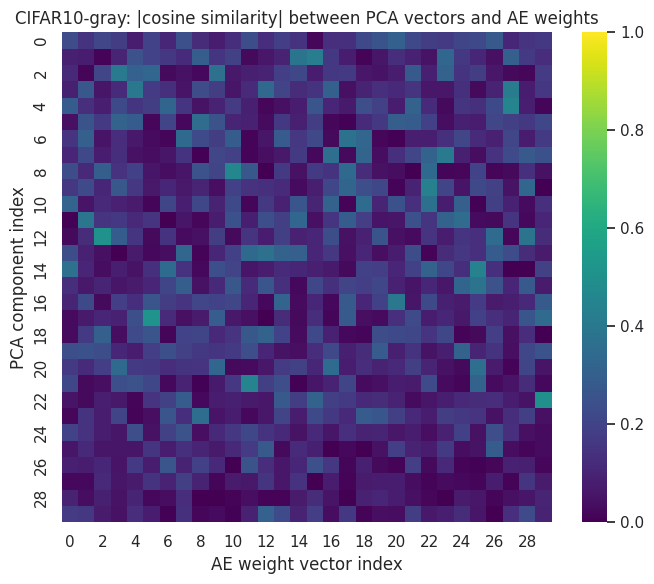

In [20]:
for ds in datasets:
    pca_components = task1_models[(ds.name, "standard PCA")]["pca"].components_
    ae_components = task2_models[ds.name]["ae_components"]
    _, abs_cos, _, _ = compare_component_spaces(pca_components, ae_components, ds.name)

    plt.figure(figsize=(7, 6))
    sns.heatmap(abs_cos, cmap="viridis", vmin=0, vmax=1)
    plt.title(f"{ds.name}: |cosine similarity| between PCA vectors and AE weights")
    plt.xlabel("AE weight vector index")
    plt.ylabel("PCA component index")
    plt.tight_layout()
    plt.show()



**Task 2 comments.**

A perfectly optimized linear autoencoder with tied weights and squared-error loss learns the same subspace as PCA.
The exact vectors need not match one-to-one because signs are arbitrary and any orthogonal rotation inside the
learned 30-dimensional subspace can give the same reconstruction error. Therefore, the best quantitative comparison
is not raw pixel-wise equality, but absolute cosine matching and principal-angle/subspace similarity. Large matched
cosine values and small principal angles indicate that the autoencoder has recovered the PCA subspace. Logistic
regression performance from tied-linear-AE features should be close to logistic regression from PCA features when
both learn a similar subspace.



# Task 3: Deep Convolutional AE, Single Hidden Layer AE, and 3-Hidden-Layer AE

All nonlinear autoencoders are trained on inputs mapped to [0, 1]. Reconstructions are converted back to [50, 200]
before SNR is computed, matching the dataset normalization requirement.

Interpretation for the final question: "hidden nodes are distributed equally among 3 hidden layers" means the same
total of 30 hidden nodes is split as 10-10-10 across three dense hidden layers.



In [21]:
def build_single_hidden_dense_ae(input_dim=784, hidden_dim=30):
    inp = keras.Input(shape=(input_dim,), name="image_flat")
    latent = layers.Dense(hidden_dim, activation="sigmoid", name="latent_30")(inp)
    out = layers.Dense(input_dim, activation="linear", name="linear_decoder")(latent)
    model = keras.Model(inp, out, name="single_hidden_sigmoid_linear_ae")
    encoder = keras.Model(inp, latent, name="single_hidden_encoder")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model, encoder


def build_three_hidden_dense_ae(input_dim=784, widths=(10, 10, 10)):
    inp = keras.Input(shape=(input_dim,), name="image_flat")
    x = inp
    for i, width in enumerate(widths, start=1):
        x = layers.Dense(width, activation="sigmoid", name=f"hidden_{i}_{width}")(x)
    out = layers.Dense(input_dim, activation="linear", name="linear_decoder")(x)
    model = keras.Model(inp, out, name="three_hidden_sigmoid_linear_ae")
    encoder = keras.Model(inp, x, name="three_hidden_encoder")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model, encoder


def build_conv_ae(latent_dim=30):
    inp = keras.Input(shape=(28, 28, 1), name="image_28x28x1")
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="linear", name="latent_30")(x)

    x = layers.Dense(7 * 7 * 128, activation="relu")(latent)
    x = layers.Reshape((7, 7, 128))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
    out = layers.Conv2D(1, 3, activation="linear", padding="same", name="linear_decoder")(x)

    model = keras.Model(inp, out, name="deep_convolutional_ae_latent30")
    encoder = keras.Model(inp, latent, name="conv_encoder_latent30")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model, encoder


def train_dense_ae_for_snr(ds, build_fn, epochs, label):
    keras.backend.clear_session()
    set_all_seeds()
    x_train = ds.x_train_flat_01.astype("float32")
    x_val = ds.x_val_flat_01.astype("float32")
    x_test = ds.x_test_flat_01.astype("float32")

    model, encoder = build_fn()
    history = model.fit(
        x_train,
        x_train,
        validation_data=(x_val, x_val),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping()],
        verbose=1,
    )
    recon_01 = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    recon_50_200 = flat01_to_50_200(recon_01)
    snr = mean_snr_db(ds.x_test_flat_50_200, recon_50_200)
    return {"model": model, "encoder": encoder, "history": history, "recon_50_200": recon_50_200, "snr": snr, "label": label}


def train_conv_ae_for_snr(ds):
    keras.backend.clear_session()
    set_all_seeds()
    x_train = to_keras_images_01(ds.x_train_01)
    x_val = to_keras_images_01(ds.x_val_01)
    x_test = to_keras_images_01(ds.x_test_01)

    model, encoder = build_conv_ae(latent_dim=N_COMPONENTS)
    model.summary()
    history = model.fit(
        x_train,
        x_train,
        validation_data=(x_val, x_val),
        epochs=CONV_AE_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping()],
        verbose=1,
    )
    recon_01 = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    recon_50_200 = flat01_to_50_200(recon_01.reshape(len(recon_01), -1))
    snr = mean_snr_db(ds.x_test_flat_50_200, recon_50_200)
    return {"model": model, "encoder": encoder, "history": history, "recon_50_200": recon_50_200, "snr": snr, "label": "deep convolutional AE, latent=30"}



In [22]:
task3_rows = []
task3_models = {}

for ds in datasets:
    print(f"\nTask 3 models for {ds.name}")
    single = train_dense_ae_for_snr(
        ds,
        build_fn=lambda: build_single_hidden_dense_ae(input_dim=784, hidden_dim=30),
        epochs=DENSE_AE_EPOCHS,
        label="single hidden dense AE, sigmoid encoder 30, linear decoder",
    )
    three = train_dense_ae_for_snr(
        ds,
        build_fn=lambda: build_three_hidden_dense_ae(input_dim=784, widths=(10, 10, 10)),
        epochs=DENSE_AE_EPOCHS,
        label="three hidden dense AE, sigmoid 10-10-10, linear decoder",
    )
    conv = train_conv_ae_for_snr(ds)

    task3_models[(ds.name, "single")] = single
    task3_models[(ds.name, "three")] = three
    task3_models[(ds.name, "conv")] = conv

    for info in [single, three, conv]:
        task3_rows.append(
            {
                "dataset": ds.name,
                "method": info["label"],
                "average_test_snr_db": info["snr"],
            }
        )

task3_results = pd.DataFrame(task3_rows)
task3_results




Task 3 models for MNIST
Epoch 1/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0875 - val_loss: 0.0683
Epoch 2/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0659 - val_loss: 0.0643
Epoch 3/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0625 - val_loss: 0.0606
Epoch 4/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0581 - val_loss: 0.0559
Epoch 5/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0533 - val_loss: 0.0514
Epoch 6/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0492 - val_loss: 0.0478
Epoch 7/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0461 - val_loss: 0.0451
Epoch 8/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0436 - val_loss: 0.0429
Epoch 1/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0985 - val_loss: 0.0825
Epoch 2/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0750 - val_loss: 0.0699
Epoch 3/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0684 - val_loss: 0.0676
Epoch 4/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.

Model: "deep_convolutional_ae_latent30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_28x28x1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_30 (Dense)               │ (None, 30)             │         3,870 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6272)           │       194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ linear_decoder (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,186,463 (4.53 MB)

 Trainable params: 1,186,463 (4.53 MB)

...

 Total params: 1,186,463 (4.53 MB)

 Trainable params: 1,186,463 (4.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 36s 980ms/step - loss: 0.1090 - val_loss: 0.0429
Epoch 2/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 976ms/step - loss: 0.0416 - val_loss: 0.0373
Epoch 3/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - loss: 0.0337 - val_loss: 0.0293
Epoch 4/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 32s 969ms/step - loss: 0.0265 - val_loss: 0.0234
Epoch 5/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 991ms/step - loss: 0.0228 - val_loss: 0.0217
Epoch 6/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 971ms/step - loss: 0.0198 - val_loss: 0.0182
Epoch 7/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - loss: 0.0174 - val_loss: 0.0162
Epoch 8/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.0158 - val_loss: 0.0151


,dataset,method,average_test_snr_db
0,MNIST,"single hidden dense AE, sigmoid encoder 30, li...",8.727330
1,MNIST,"three hidden dense AE, sigmoid 10-10-10, linea...",6.735291
2,MNIST,"deep convolutional AE, latent=30",14.545450
3,CIFAR10-gray,"single hidden dense AE, sigmoid encoder 30, li...",13.528052
4,CIFAR10-gray,"three hidden dense AE, sigmoid 10-10-10, linea...",12.004028
5,CIFAR10-gray,"deep convolutional AE, latent=30",17.254794


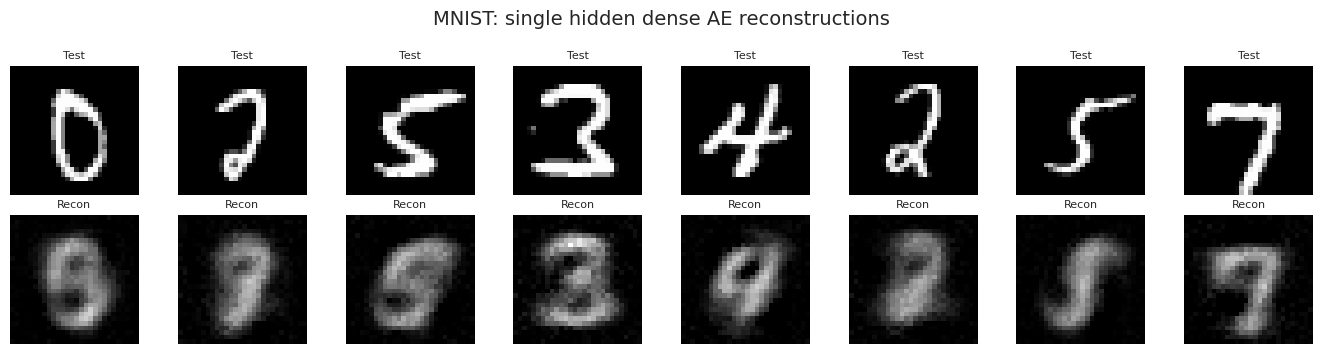

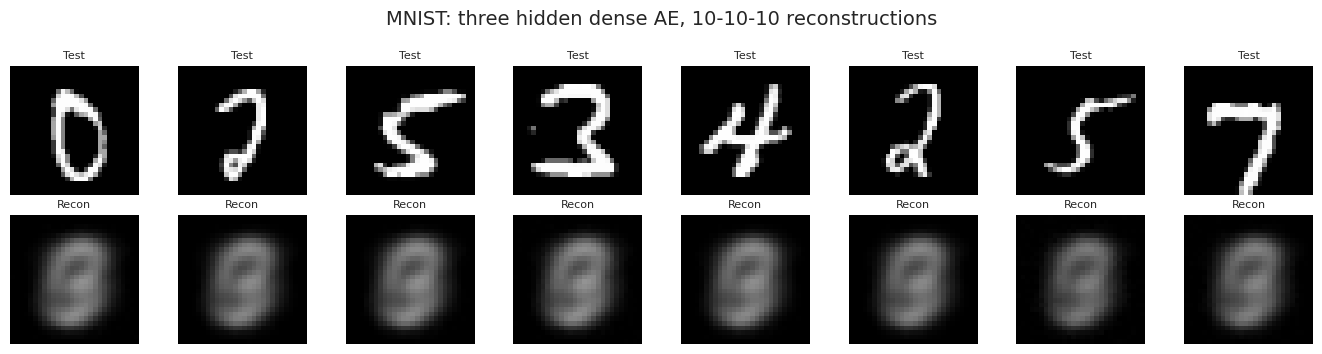

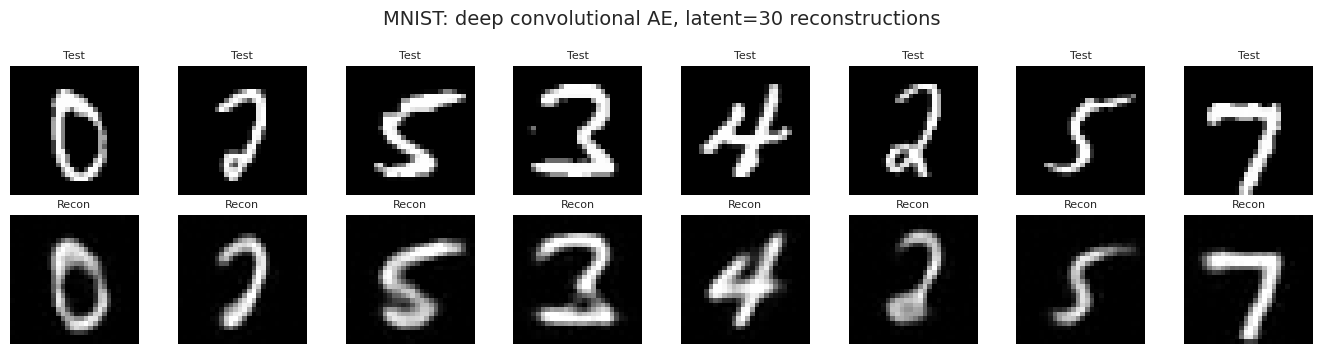

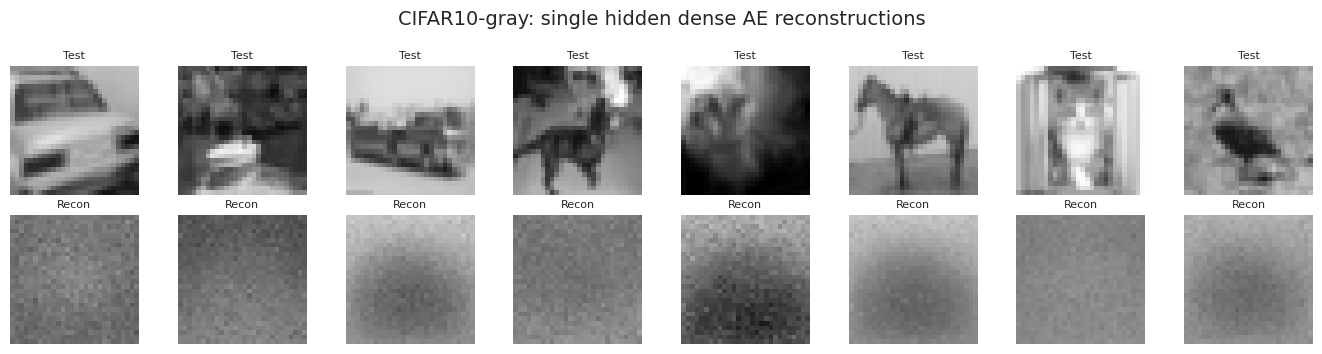

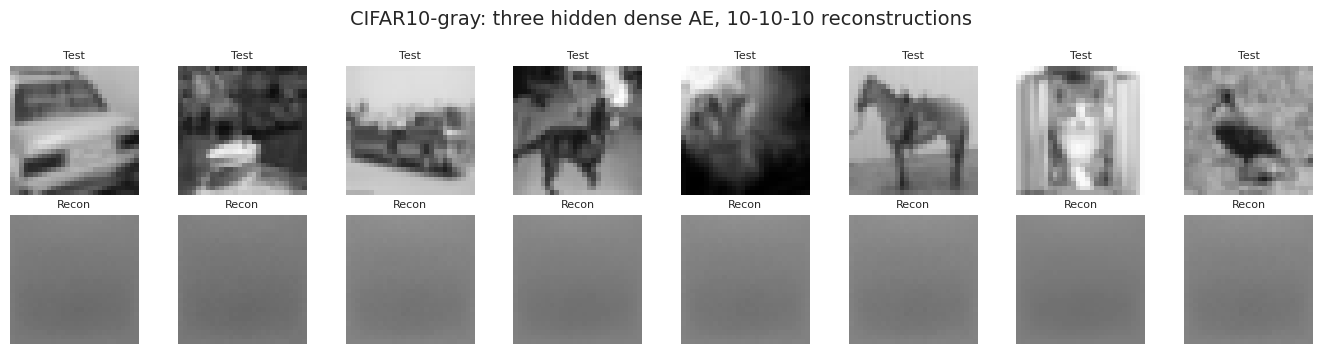

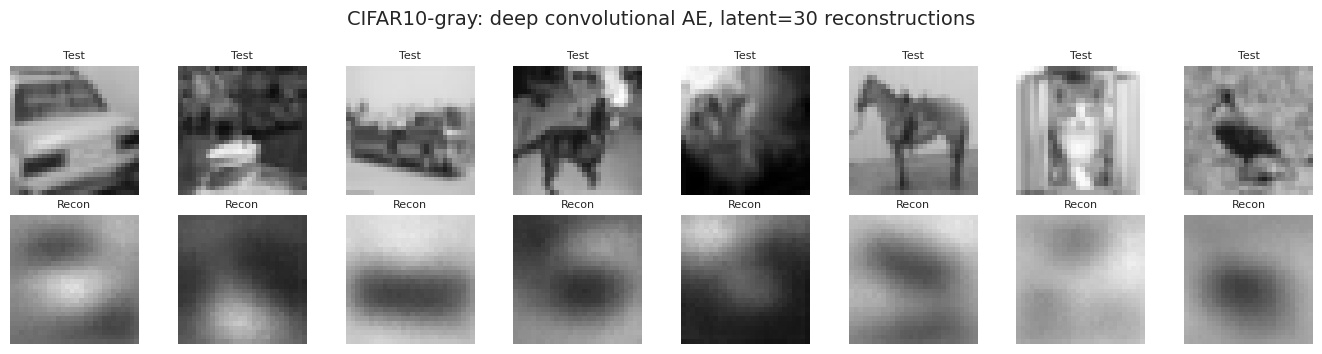

In [23]:
for ds in datasets:
    for key, title in [
        ("single", "single hidden dense AE"),
        ("three", "three hidden dense AE, 10-10-10"),
        ("conv", "deep convolutional AE, latent=30"),
    ]:
        recon = task3_models[(ds.name, key)]["recon_50_200"]
        plot_reconstruction_examples(ds.x_test_flat_50_200, recon, f"{ds.name}: {title} reconstructions")



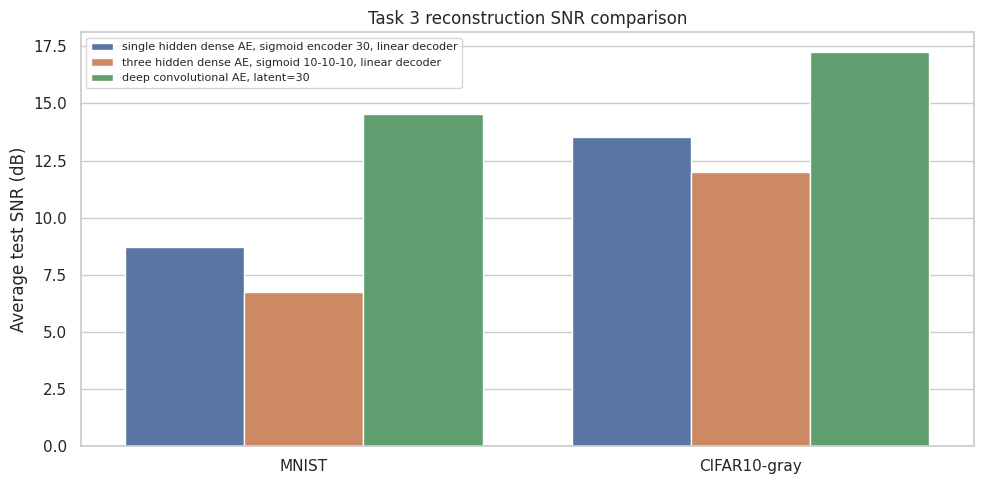

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(data=task3_results, x="dataset", y="average_test_snr_db", hue="method")
plt.title("Task 3 reconstruction SNR comparison")
plt.ylabel("Average test SNR (dB)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()



**Task 3 comments.**

The convolutional autoencoder is expected to achieve the highest SNR because convolutional filters exploit spatial
locality and weight sharing. The single hidden layer dense autoencoder with only 30 sigmoid hidden nodes is a much
stronger bottleneck and ignores image geometry. The three-hidden-layer dense model uses the same total hidden-node
budget split as 10-10-10, so the effective bottleneck is only 10 dimensions; it normally reconstructs worse than the
30-node single hidden layer model, especially for gray CIFAR10. MNIST is usually easier to reconstruct than CIFAR10
because digits are sparse and structurally simpler.



# Final Summary Tables



In [25]:
print("Task 1: PCA and randomized PCA")
display(task1_results)

print("Task 2: PCA versus tied linear AE classification and SNR")
display(
    pd.concat(
        [
            task1_results.query("method == 'standard PCA'")[
                ["dataset", "method", "components", "accuracy", "macro_auc_ovr", "average_test_snr_db"]
            ],
            task2_results,
        ],
        ignore_index=True,
    )
)

print("Task 2: quantitative component relationship")
display(component_comparison)

print("Task 3: nonlinear autoencoder SNR")
display(task3_results)



Task 1: PCA and randomized PCA


,dataset,method,components,accuracy,macro_auc_ovr,explained_variance_ratio_sum,average_test_snr_db
0,MNIST,standard PCA,30,0.904167,0.988758,0.733744,12.575018
1,MNIST,randomized PCA,30,0.904167,0.988550,0.733691,12.573960
2,CIFAR10-gray,standard PCA,30,0.282500,0.711971,0.851137,20.003669
3,CIFAR10-gray,randomized PCA,30,0.285000,0.711737,0.851111,20.000278


Task 2: PCA versus tied linear AE classification and SNR


,dataset,method,components,accuracy,macro_auc_ovr,average_test_snr_db
0,MNIST,standard PCA,30,0.904167,0.988758,12.575018
1,CIFAR10-gray,standard PCA,30,0.282500,0.711971,20.003669
2,MNIST,tied linear AE features,30,0.900000,0.989927,11.297852
3,CIFAR10-gray,tied linear AE features,30,0.288333,0.712465,19.590946


Task 2: quantitative component relationship


,dataset,mean_matched_abs_cosine,median_matched_abs_cosine,min_matched_abs_cosine,mean_subspace_singular_value,max_principal_angle_deg
0,MNIST,0.303689,0.290515,0.079505,0.720208,87.911797
1,CIFAR10-gray,0.354050,0.368258,0.124365,0.879534,88.398766


Task 3: nonlinear autoencoder SNR


,dataset,method,average_test_snr_db
0,MNIST,"single hidden dense AE, sigmoid encoder 30, li...",8.727330
1,MNIST,"three hidden dense AE, sigmoid 10-10-10, linea...",6.735291
2,MNIST,"deep convolutional AE, latent=30",14.545450
3,CIFAR10-gray,"single hidden dense AE, sigmoid encoder 30, li...",13.528052
4,CIFAR10-gray,"three hidden dense AE, sigmoid 10-10-10, linea...",12.004028
5,CIFAR10-gray,"deep convolutional AE, latent=30",17.254794


## Final Observations and Conclusion

For Task 1, standard PCA and randomized PCA produced almost identical results. On MNIST, both methods achieved about 90.4% accuracy with macro AUC close to 0.989. On CIFAR10-gray, the accuracy was lower, around 28%, because CIFAR10 contains more complex natural images even after conversion to grayscale. The reconstruction SNR was higher for CIFAR10-gray than MNIST, mainly because CIFAR images have smoother global intensity structure after grayscale resizing.

For Task 2, the tied-weight linear autoencoder gave classification performance very close to PCA. On MNIST, the tied linear AE achieved about 90.0% accuracy, close to PCA's 90.4%. On CIFAR10-gray, the tied linear AE slightly improved accuracy compared with standard PCA. This supports the theoretical relationship that a linear autoencoder with tied weights learns a PCA-like subspace. However, the individual vectors do not need to match exactly because signs and rotations inside the learned subspace can differ.

For Task 3, the deep convolutional autoencoder gave the best reconstruction SNR for both datasets. The single hidden layer dense autoencoder performed worse than the convolutional autoencoder, and the three-hidden-layer dense autoencoder with 10-10-10 hidden nodes had lower SNR because the effective bottleneck is very small. The final SNR values were approximately 14.55 dB for MNIST and 17.25 dB for CIFAR10-gray using the convolutional autoencoder.
